In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler

# Configuración de reproducibilidad
np.random.seed(42)

def generar_datos_prestamos(n=2000):
    # Generación de 17 variables profesionales
    data = {
        'ID_Cliente': range(n),
        'Edad': np.random.randint(18, 75, n),
        'Ingresos_Anuales': np.random.gamma(shape=5, scale=10000, size=n),
        'Puntaje_Credito': np.random.randint(300, 850, n),
        'Monto_Prestamo': np.random.gamma(shape=3, scale=5000, size=n),
        'Tasa_Interes': np.random.uniform(0.05, 0.25, n),
        'Ratio_Deuda_Ingreso': np.random.uniform(0.1, 0.6, n),
        'Antiguedad_Empleo_Meses': np.random.randint(0, 360, n),
        'Num_Tarjetas_Credito': np.random.randint(0, 10, n),
        'Num_Prestamos_Activos': np.random.randint(0, 5, n),
        'Historial_Morosidad_6m': np.random.choice([0, 1, 2], n, p=[0.8, 0.15, 0.05]),
        'Estado_Civil': np.random.choice([0, 1, 2], n), # 0: Soltero, 1: Casado, 2: Divorciado
        'Propiedad_Vivienda': np.random.choice([0, 1], n, p=[0.4, 0.6]),
        'Ahorros_Totales': np.random.gamma(shape=2, scale=2000, size=n),
        'Gastos_Mensuales_Fijos': np.random.normal(2000, 500, n),
        'Educacion_Nivel': np.random.choice([0, 1, 2, 3], n),
        'Uso_Linea_Credito': np.random.uniform(0.0, 1.0, n)
    }
    
    df = pd.DataFrame(data)
    
    # Lógica para crear el Target (Morosidad)
    # El riesgo sube si: bajo puntaje, alta deuda/ingreso, uso alto de línea y morosidad previa
    logit = (df['Ratio_Deuda_Ingreso'] * 4 + 
             df['Uso_Linea_Credito'] * 3 + 
             df['Historial_Morosidad_6m'] * 2 - 
             (df['Puntaje_Credito'] / 200) - 
             (df['Ahorros_Totales'] / 5000))
    
    prob = 1 / (1 + np.exp(-logit + 2))
    df['Target_Morosidad'] = (prob > np.random.uniform(0, 1, n)).astype(int)
    
    return df

df_banco = generar_datos_prestamos()
print(f"Dataset generado: {df_banco.shape}")

Dataset generado: (2000, 18)


2. EDA: Análisis Exploratorio de Datos

Es vital identificar qué variables separan mejor a los morosos de los pagadores puntuales.

/var/folders/wz/hfsksc4d0h1gqgq5z6wld3vr0000gn/T/ipykernel_59644/2938907521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target_Morosidad', y='Puntaje_Credito', data=df_banco, palette='Set2')


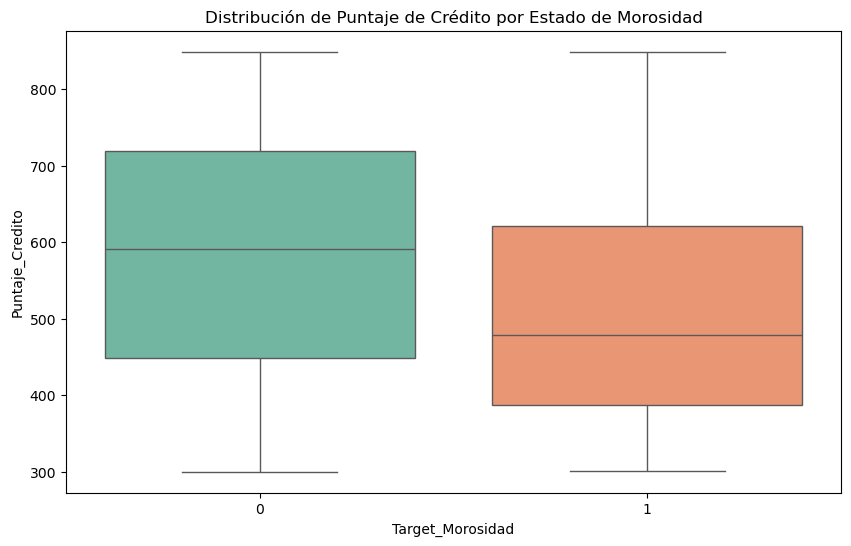

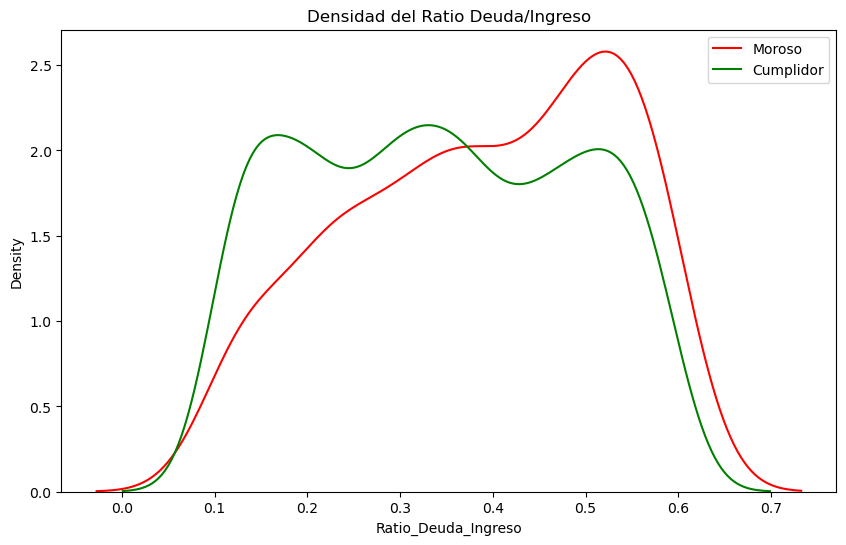

In [2]:
# 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target_Morosidad', y='Puntaje_Credito', data=df_banco, palette='Set2')
plt.title("Distribución de Puntaje de Crédito por Estado de Morosidad")
plt.show()

# Visualización de la relación Deuda/Ingreso
plt.figure(figsize=(10, 6))
sns.kdeplot(df_banco[df_banco['Target_Morosidad'] == 1]['Ratio_Deuda_Ingreso'], label='Moroso', color='red')
sns.kdeplot(df_banco[df_banco['Target_Morosidad'] == 0]['Ratio_Deuda_Ingreso'], label='Cumplidor', color='green')
plt.title("Densidad del Ratio Deuda/Ingreso")
plt.legend()
plt.show()

3. Entrenamiento y Predicciones (XGBoost)

In [3]:
X = df_banco.drop(['ID_Cliente', 'Target_Morosidad'], axis=1)
y = df_banco['Target_Morosidad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Modelo XGBoost
model_default = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, scale_pos_weight=3)
model_default.fit(X_train, y_train)

# Predicciones de probabilidad y clase
y_probs = model_default.predict_proba(X_test)[:, 1]
y_preds = (y_probs > 0.5).astype(int)

4. Evaluación del Modelo (Métricas Financieras)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       412
           1       0.58      0.56      0.57        88

    accuracy                           0.85       500
   macro avg       0.74      0.73      0.74       500
weighted avg       0.85      0.85      0.85       500

ROC-AUC Score: 0.8431


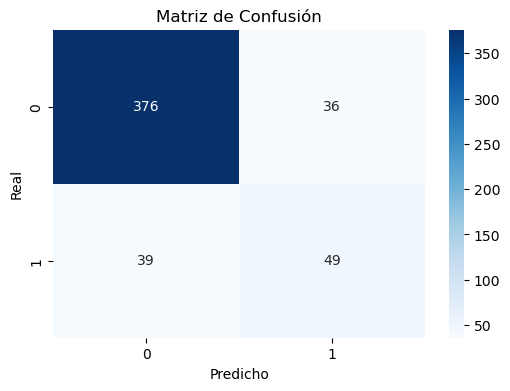

In [4]:
# 
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_preds))

auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title('Matriz de Confusión')
plt.show()

5. Análisis de Riesgo Individual y Probabilidades

Clasificamos a los clientes según su probabilidad predicha.

In [5]:
def clasificar_riesgo_cliente(prob):
    if prob < 0.20: return "Riesgo Bajo", prob
    elif prob < 0.60: return "Riesgo Medio", prob
    else: return "Riesgo Alto", prob

# Ejemplo con los primeros 5 clientes del test set
resultados_riesgo = pd.DataFrame({
    'Probabilidad_Default': y_probs[:5]
})
resultados_riesgo[['Nivel_Riesgo', 'Prob_Exacta']] = resultados_riesgo['Probabilidad_Default'].apply(
    lambda x: pd.Series(clasificar_riesgo_cliente(x))
)
print("\n--- CLASIFICACIÓN DE RIESGO ---")
print(resultados_riesgo)


--- CLASIFICACIÓN DE RIESGO ---
   Probabilidad_Default  Nivel_Riesgo  Prob_Exacta
0              0.219283  Riesgo Medio     0.219283
1              0.500082  Riesgo Medio     0.500082
2              0.013378   Riesgo Bajo     0.013378
3              0.019465   Riesgo Bajo     0.019465
4              0.066504   Riesgo Bajo     0.066504


6. Análisis de Sensibilidad y Stress Test

Simulamos un escenario de crisis económica donde el desempleo sube y los ingresos caen.


--- STRESS TEST: CRISIS ECONÓMICA ---
Tasa de Morosidad Base: 17.00%
Tasa de Morosidad en Estrés: 25.40%
Incremento relativo en fallidos: 49.41%


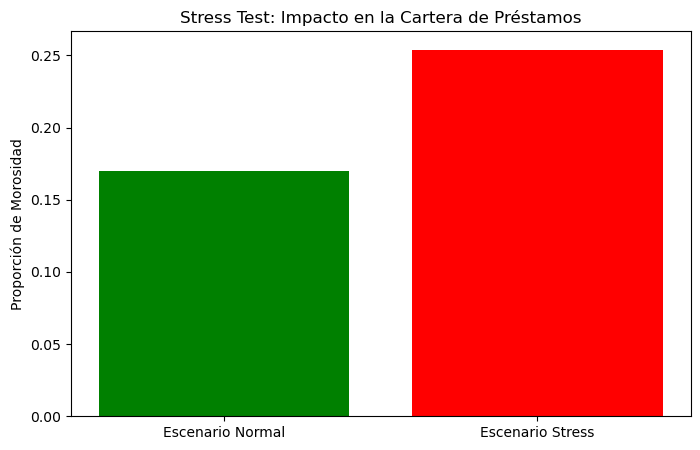

In [6]:
# 
print("\n--- STRESS TEST: CRISIS ECONÓMICA ---")

# Escenario: Caída del 20% en ingresos y aumento del 30% en ratio deuda/ingreso
X_test_stress = X_test.copy()
X_test_stress['Ingresos_Anuales'] *= 0.80
X_test_stress['Ratio_Deuda_Ingreso'] *= 1.30
X_test_stress['Uso_Linea_Credito'] *= 1.20

y_probs_stress = model_default.predict_proba(X_test_stress)[:, 1]
morosidad_base = (y_probs > 0.5).mean()
morosidad_stress = (y_probs_stress > 0.5).mean()

print(f"Tasa de Morosidad Base: {morosidad_base:.2%}")
print(f"Tasa de Morosidad en Estrés: {morosidad_stress:.2%}")
print(f"Incremento relativo en fallidos: {((morosidad_stress/morosidad_base)-1):.2%}")

# Visualización del Impacto
plt.figure(figsize=(8, 5))
plt.bar(['Escenario Normal', 'Escenario Stress'], [morosidad_base, morosidad_stress], color=['green', 'red'])
plt.ylabel('Proporción de Morosidad')
plt.title('Stress Test: Impacto en la Cartera de Préstamos')
plt.show()

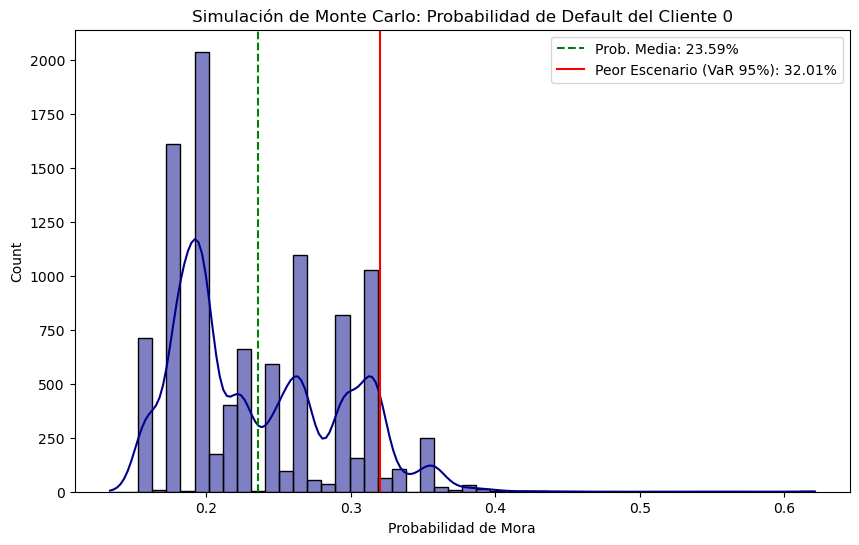

Resultado del Análisis de Monte Carlo:
- Clasificación Final: RIESGO MEDIO (Sensible a Shocks)
- Riesgo de Cola (Peor caso 5%): 32.01%


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 7. MÓDULO: SIMULACIÓN DE MONTE CARLO SOBRE XGBOOST
# =============================================================================

def monte_carlo_credit_risk(model, client_data, n_simulations=1000):
    """
    Realiza simulaciones de Monte Carlo variando ligeramente los datos 
    del cliente para observar la estabilidad de su riesgo.
    """
    # 
    
    # Definimos la volatilidad de las variables (Shocks aleatorios)
    # Por ejemplo, el ingreso puede variar +/- 10% y el uso de crédito +/- 5%
    simulated_data = pd.concat([client_data] * n_simulations, ignore_index=True)
    
    # Aplicamos ruido gaussiano a variables críticas
    simulated_data['Ingresos_Anuales'] *= np.random.normal(1.0, 0.10, n_simulations)
    simulated_data['Uso_Linea_Credito'] = np.clip(
        simulated_data['Uso_Linea_Credito'] + np.random.normal(0, 0.05, n_simulations), 0, 1
    )
    simulated_data['Puntaje_Credito'] = np.clip(
        simulated_data['Puntaje_Credito'] + np.random.normal(0, 15, n_simulations), 300, 850
    )
    
    # Predecimos probabilidades para todos los escenarios simulados
    probs_simuladas = model.predict_proba(simulated_data)[:, 1]
    
    return probs_simuladas

# --- Ejecución para un Cliente de Prueba ---
# Tomamos un cliente del test set (por ejemplo, el primero)
cliente_index = 0
data_cliente = X_test.iloc[[cliente_index]]

# Ejecutar 10,000 iteraciones para este cliente
resultados_mc = monte_carlo_credit_risk(model_default, data_cliente, n_simulations=10000)

# --- VISUALIZACIÓN Y CLASIFICACIÓN DE RESULTADOS ---
prob_media = np.mean(resultados_mc)
limite_superior = np.percentile(resultados_mc, 95) # Valor en Riesgo (VaR) al 95%

plt.figure(figsize=(10, 6))
sns.histplot(resultados_mc, kde=True, color='darkblue', bins=50)
plt.axvline(prob_media, color='green', linestyle='--', label=f'Prob. Media: {prob_media:.2%}')
plt.axvline(limite_superior, color='red', linestyle='-', label=f'Peor Escenario (VaR 95%): {limite_superior:.2%}')
plt.title(f"Simulación de Monte Carlo: Probabilidad de Default del Cliente {cliente_index}")
plt.xlabel("Probabilidad de Mora")
plt.legend()
plt.show()

# --- CLASIFICACIÓN BASADA EN MONTE CARLO ---
def clasificar_riesgo_mc(prob_mean, prob_max):
    # Clasificación por robustez
    if prob_max < 0.25:
        return "RIESGO BAJO (Perfil Sólido)"
    elif prob_mean < 0.50 and prob_max < 0.70:
        return "RIESGO MEDIO (Sensible a Shocks)"
    else:
        return "RIESGO ALTO (Alta Vulnerabilidad)"

nivel_final = clasificar_riesgo_mc(prob_media, limite_superior)
print(f"Resultado del Análisis de Monte Carlo:")
print(f"- Clasificación Final: {nivel_final}")
print(f"- Riesgo de Cola (Peor caso 5%): {limite_superior:.2%}")

Explicación de los pasos añadidos:

Variabilidad Estocástica: En lugar de asumir que los ingresos del cliente son estáticos, la simulación asume que pueden fluctuar (por pérdida de horas extras, cambios en el mercado, etc.). Inyectamos ruido en el Puntaje de Crédito y en el Uso de la Línea.

Distribución de Resultados: El gráfico resultante no es un punto, sino una curva. Si la curva es muy "ancha", significa que el cliente es muy inestable; si es "estrecha", su perfil de riesgo es predecible.

VaR (Value at Risk) Actuarial: El umbral del 95% nos indica qué tan grave podría ser el riesgo en un escenario de estrés moderado.

Clasificación Robusta: Clasificamos al cliente no solo por su probabilidad hoy, sino por cómo se comporta en los 10,000 escenarios.

¿Qué ganamos con esto?

Esto permite al banco detectar clientes que hoy parecen "buenos" (Riesgo Bajo), pero que ante una pequeña caída en sus ingresos se convierten rápidamente en "malos" (Riesgo Alto). Es una técnica de análisis de resiliencia financiera.